# Support Vector Machine — Classificação do Estado do Tabuleiro

Mesmo dataset e mesma estratégia de GridSearchCV do notebook de Random Forest (`04_random_forest.ipynb`), substituindo o modelo pelo **SVM**.

---
### Como funciona o SVM
O SVM encontra o **hiperplano de margem máxima** que separa as classes no espaço de features. Para dados não-linearmente separáveis, o **kernel trick** projeta implicitamente os dados em um espaço de maior dimensão onde a separação linear é possível — sem calcular explicitamente essa projeção.

No modo multiclasse, é usado o esquema **One-vs-Rest (OvR)**: um classificador binário por classe, e a classe com maior score de decisão vence.

### Por que o StandardScaler é necessário
O SVM é altamente sensível à escala das features: a margem e o kernel RBF dependem de distâncias euclidianas. Features em escalas diferentes distorcem essas distâncias e penalizam injustamente alguns pesos. O `StandardScaler` é encapsulado no Pipeline para que o arquivo `.pkl` seja autossuficiente — o app chama `model.predict(tabuleiro_bruto)` diretamente.

### Parâmetros principais
- **C**: penalidade por erro de classificação — valores altos = menos margem, mais ajuste aos dados
- **kernel**: função de transformação do espaço (`rbf`, `linear`)
- **gamma**: alcance de influência de cada amostra no kernel RBF (`scale`, `auto`)

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

print("Carregando os dados...")
df = pd.read_csv('../../data/processed/preprocessed_1.csv')

X = df.drop('classe', axis=1)  # As 9 posições do tabuleiro (pos_1 .. pos_9)
y = df['classe']               # As 4 classes

print(f"Dataset: {df.shape[0]} amostras, {df.shape[1]-1} features")
print("\nDistribuição das classes:")
print(y.value_counts())

Carregando os dados...
Dataset: 1600 amostras, 9 features

Distribuição das classes:
classe
X venceu    626
Tem jogo    626
O venceu    316
Empate       32
Name: count, dtype: int64


In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classes mapeadas: {list(le.classes_)}")

# X não é escalado aqui — o Pipeline aplica o StandardScaler internamente.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTamanho do Treino: {len(X_train)} amostras")
print(f"Tamanho do Teste:  {len(X_test)} amostras")

Classes mapeadas: ['Empate', 'O venceu', 'Tem jogo', 'X venceu']

Tamanho do Treino: 1280 amostras
Tamanho do Teste:  320 amostras


In [6]:
# Prefixo "svc__" direciona os parâmetros ao passo SVC dentro do Pipeline.
param_grid = {
    'svc__C':            [0.1, 1, 10, 100],
    'svc__kernel':       ['rbf', 'linear'],
    'svc__gamma':        ['scale', 'auto'],
    'svc__class_weight': ['balanced', None],
}

pipeline_base = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(random_state=42, decision_function_shape='ovr')),
])

grid_search = GridSearchCV(
    estimator=pipeline_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Iniciando GridSearchCV...")
grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1 (CV): {grid_search.best_score_:.4f}")

Iniciando GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Melhores parâmetros encontrados:
  svc__C: 100
  svc__class_weight: balanced
  svc__gamma: scale
  svc__kernel: rbf

Melhor F1 (CV): 0.9668


In [7]:
svm_model = grid_search.best_estimator_
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

acc_treino = svm_model.score(X_train, y_train)
acc_teste  = svm_model.score(X_test,  y_test)
print(f"Acurácia no Treino: {acc_treino:.4f}")
print(f"Acurácia no Teste:  {acc_teste:.4f}")

if acc_treino - acc_teste > 0.05:
    print("\n⚠️  Diferença > 5pp entre treino e teste — possível overfitting.")
else:
    print("\n✅  Diferença treino/teste dentro do esperado.")

Acurácia no Treino: 1.0000
Acurácia no Teste:  0.9719

✅  Diferença treino/teste dentro do esperado.


## 5. Avaliação: Relatório de Classificação e Matriz de Confusão

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

      Empate       0.57      0.57      0.57         7
    O venceu       0.98      1.00      0.99        63
    Tem jogo       0.98      0.95      0.96       125
    X venceu       0.98      1.00      0.99       125

    accuracy                           0.97       320
   macro avg       0.88      0.88      0.88       320
weighted avg       0.97      0.97      0.97       320



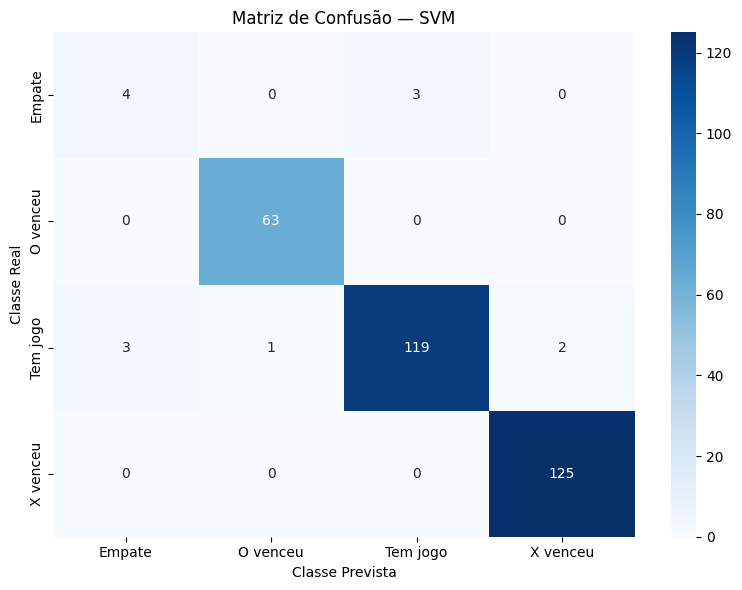

In [8]:
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — SVM')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.show()

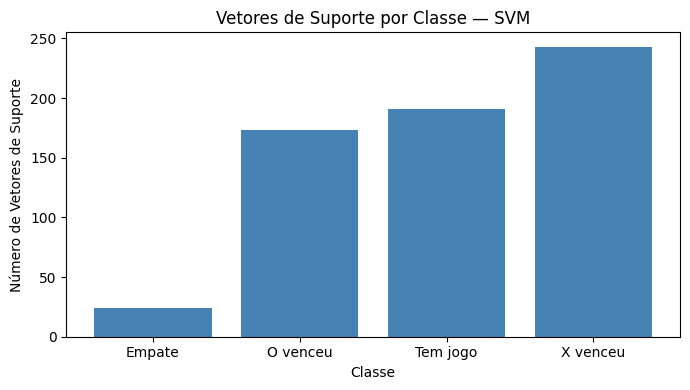

Total de vetores de suporte: 631
  Empate: 24
  O venceu: 173
  Tem jogo: 191
  X venceu: 243


In [9]:
# Número de vetores de suporte por classe — quanto maior, mais complexa a fronteira de decisão.
svc_step = svm_model.named_steps['svc']
sv_counts = dict(zip(le.classes_, svc_step.n_support_))

plt.figure(figsize=(7, 4))
plt.bar(sv_counts.keys(), sv_counts.values(), color='steelblue')
plt.title('Vetores de Suporte por Classe — SVM')
plt.xlabel('Classe')
plt.ylabel('Número de Vetores de Suporte')
plt.tight_layout()
plt.show()

print(f"Total de vetores de suporte: {svc_step.n_support_.sum()}")
for classe, n in sv_counts.items():
    print(f"  {classe}: {n}")

In [10]:
os.makedirs('../../models/SVM', exist_ok=True)

# O Pipeline já contém o StandardScaler internamente — apenas dois arquivos necessários,
# compatível com o carregamento dinâmico do app (model + encoder).
joblib.dump(svm_model, '../../models/SVM/svm_model.pkl')
joblib.dump(le,        '../../models/SVM/svm_label_encoder.pkl')

print("Modelo (Pipeline) e Encoder salvos com sucesso!")
print("  -> ../../models/SVM/svm_model.pkl")
print("  -> ../../models/SVM/svm_label_encoder.pkl")

Modelo (Pipeline) e Encoder salvos com sucesso!
  -> ../../models/SVM/svm_model.pkl
  -> ../../models/SVM/svm_label_encoder.pkl
